In [1]:
import numpy as np
import matplotlib.pyplot as plt
from plot import make_theme

%matplotlib inline
plt.rcParams['font.size'] = 7

In [2]:
def plot_label(ax, count, x=0, y=1.03, color='k'):
    ax.text(x, y, count, fontdict=dict(fontsize=9), transform=ax.transAxes, color=color, weight='bold')

In [3]:
honeycomb = []
lattice = np.load('../codes/honeycomb.npy')[:2,:]
for site1 in range(lattice.shape[1]-1):
    for site2 in np.arange(site1+1,lattice.shape[1]):
        r1 = lattice[:,site1]
        r2 = lattice[:,site2]
        if abs((r1[0]-r2[0])**2+(r1[1]-r2[1])**2-1.)<=1e-3:
            for ax in axs[:2]:
                honeycomb.append([r1[0], r2[0], r1[1], r2[1]])

NameError: name 'axs' is not defined

Text(0, 0.5, 'Intensity (arb. units)')

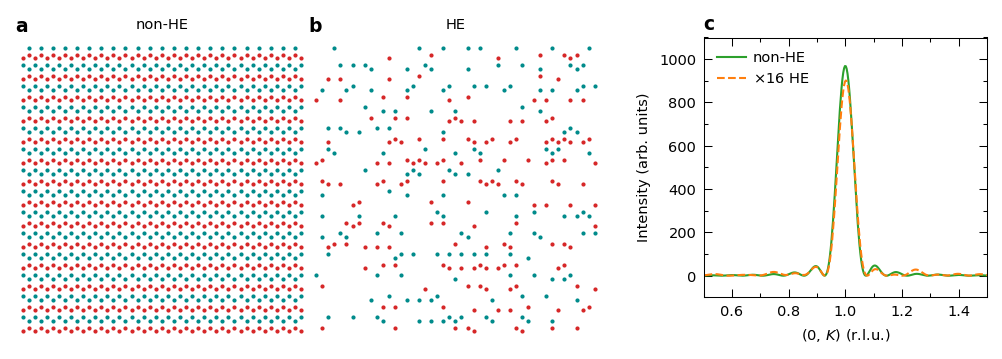

In [4]:
fig = plt.figure(figsize=(6.75,6.75/3.), dpi=150)
gs1 = fig.add_gridspec(nrows=1, ncols=2, left=0.02, right=0.60, top=0.93, bottom=0.02, wspace=0, hspace=0)
gs2 = fig.add_gridspec(nrows=1, ncols=1, left=0.70, right=0.98, top=0.92, bottom=0.15, wspace=0, hspace=0)
axs = [fig.add_subplot(gs) for gs in gs1] + [fig.add_subplot(gs) for gs in gs2]

# honeycomb lattice
for ax in axs[:2]:
    for line in honeycomb:
        ax.plot(line[:2], line[2:], '-', lw=0.5, color='lightgray', zorder=-10)

# non-HE
data = np.load('../codes/honeycomb.npy')
lattice = data[:2,:]
spins = data[2]
plot_params = dict(ms=2, ls='none')
choose = spins<-0.5
axs[0].plot(lattice[0,choose], lattice[1,choose], '.', color='darkcyan', **plot_params)
choose = spins>0.5
axs[0].plot(lattice[0,choose], lattice[1,choose], '.', color='C3', **plot_params)

# HE
data = np.load('../codes/honeycomb_HE.npy')
lattice = data[:2,:]
spins = data[2]
choose = np.logical_and(spins<-0.5, spins>-1.5)
axs[1].plot(lattice[0,choose], lattice[1,choose], '.', color='darkcyan', **plot_params)
choose = np.logical_and(spins>0.5, spins<1.5)
axs[1].plot(lattice[0,choose], lattice[1,choose], '.', color='C3', **plot_params)

# scan
data = dict(np.load('../codes/I_honeycomb.npz'))
axs[2].plot(data['Krlu'], data['I'], '-', lw=1, color='C2', label='non-HE')
data = dict(np.load('../codes/I_honeycomb_HE.npz'))
axs[2].plot(data['Krlu'], data['I']*16, '--', lw=1, color='C1', label='$\\times16$ HE')
axs[2].legend(frameon=False, loc='upper left', handletextpad=0.5)

for ax in axs[:2]:
    ax.set_aspect('equal')
    ax.set_xlim(-21,21)
    ax.set_ylim(-21,21)
    ax.axis('off')
for ax, count in zip(axs, ['a','b','c']):
    plot_label(ax, count, x=0, y=1.03)
make_theme(axs[2], ticklength=4)
axs[0].set_title('non-HE', fontsize=7)
axs[1].set_title('HE', fontsize=7)
axs[2].set_xlim(0.5,1.5)
axs[2].set_xlabel('(0, $K$) (r.l.u.)')
axs[2].set_ylim(-100,1100)
axs[2].set_ylabel('Intensity (arb. units)')

# fig.savefig('model.pdf')